<a href="https://colab.research.google.com/github/tayaland1514/statprak_hw/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Загрузка данных и EDA

In [1]:
import pandas as pd

df = pd.read_csv("datasets/cs-training.csv")

Переименовываем часть столбцов, чтобы было понятно, что означает каждый из них

In [2]:
df = df.rename(columns={
    "SeriousDlqin2yrs": "default",
    "RevolvingUtilizationOfUnsecuredLines": "credit_utilization",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59_days",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "num_credit_lines",
    "NumberOfTimes90DaysLate": "late_90_days",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89_days",
    "NumberOfDependents": "dependents"
})

In [3]:
df.head()

,Unnamed: 0,default,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Первый столбец — это целевая переменная `default`

Она показывает, была ли у заёмщика серьёзная просрочка по кредиту:
- 0 — просрочки более чем на 90 дней не было
- 1 — была просрочка более чем на 90 дней

`default` — это переменная, которую в дальнейшем необходимо будет предсказывать, используя признаки заёмщика

Признаки заёмщика (остальные столбцы):

- `credit_utilization` — доля использованного кредитного лимита
- `age` — возраст заёмщика
- `late_30_59_days` — количество просрочек на 30–59 дней
- `late_60_89_days` — количество просрочек на 60–89 дней
- `late_90_days` — количество просрочек более чем на 90 дней
- `debt_ratio` — отношение ежемесячных платежей по долгам к ежемесячному доходу
- `monthly_income` — ежемесячный доход
- `num_credit_lines` — количество открытых кредитных линий
- `real_estate_loans` — количество кредитов на недвижимость
- `dependents` — количество иждивенцев

Далее построим корреляционную матрицу признаков, чтобы:
- выявить сильные зависимости между признаками, которые могут влиять на работу моделей
- проверить, есть ли признаки, сильно коррелирующие с целевой переменной `default`

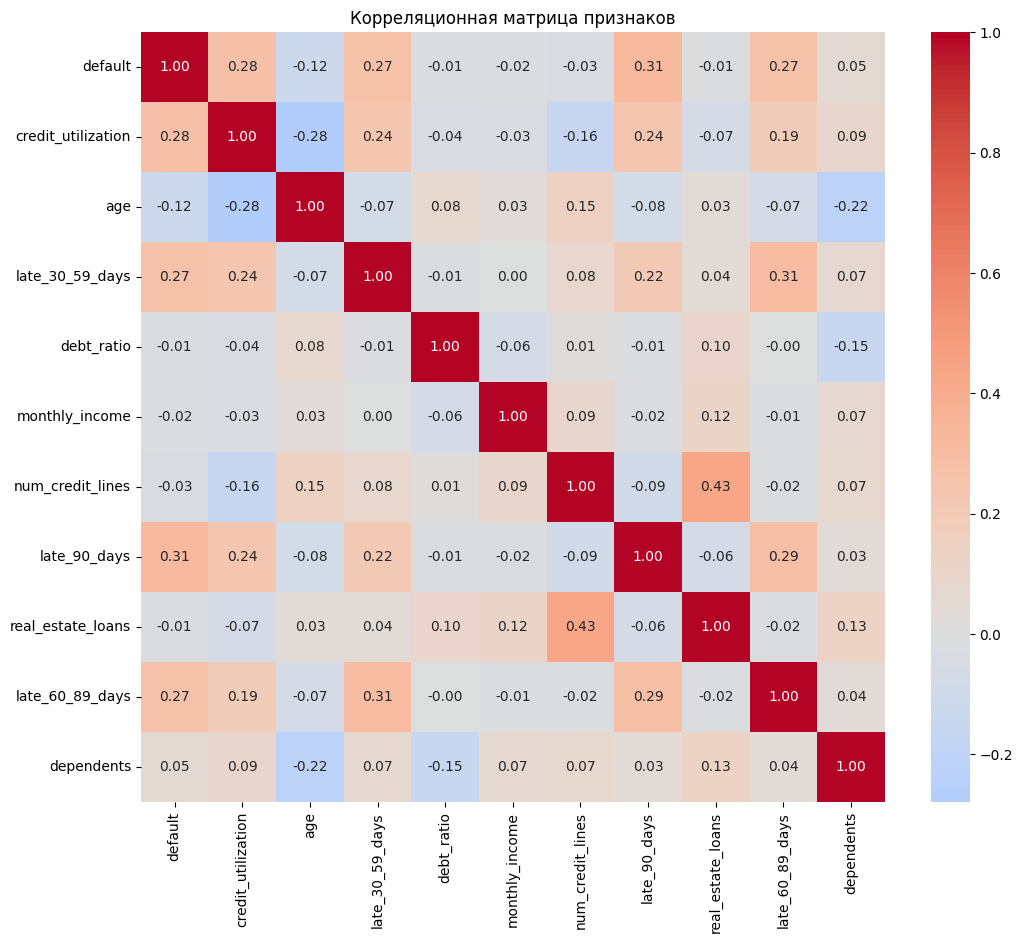

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cols_to_check = [
    'default', 'credit_utilization', 'age',
    'late_30_59_days', 'debt_ratio', 'monthly_income',
    'num_credit_lines', 'late_90_days', 'real_estate_loans',
    'late_60_89_days', 'dependents'
]

plt.figure(figsize=(12, 10))
corr_matrix = df[cols_to_check].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Корреляционная матрица признаков")
plt.show()

- Сильных зависимостей между признаками, которые могут влиять на работу моделей, нет
- Признаков, сильно коррелирующих с целевой переменной `default`, тоже нет
- Признаки не дублируют друг друга и могут использоваться совместно в модели


Далее посмотрим на дисбаланс классов:

In [18]:
df["default"].value_counts(normalize=True)

,proportion
default,
0,0.93316
1,0.06684


Целевая переменная несбалансированная - будем это учитывать при оценке качества моделей

Далее построим гистограмму всех встречающихся возрастов, чтобы понять, как распределены значения и есть ли какие-то аномалии или выбросы

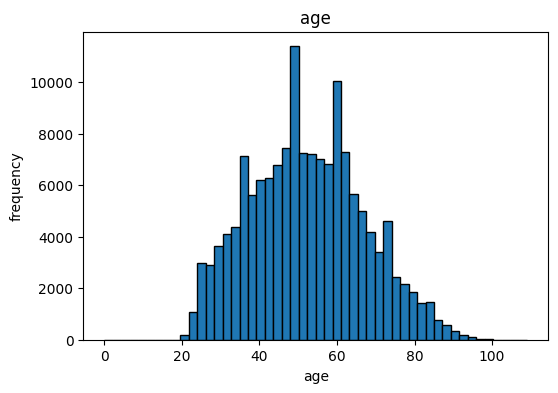

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(df["age"].dropna(), bins=50, edgecolor="black")
plt.title("age")
plt.xlabel("age")
plt.ylabel("frequency")
plt.show()

Проверим, есть ли аномальные значения среди возрастов заемщиков:

In [16]:

df["age"].value_counts().sort_index().tail(10)

,count
age,
96,18
97,17
98,6
99,9
101,3
102,3
103,3
105,1
107,1


In [17]:
df["age"].value_counts().sort_index().head(10)

,count
age,
0,1
21,183
22,434
23,641
24,816
25,953
26,1193
27,1338
28,1560


Заемщику не может быть 0 лет, и два 109-летних заемщика (а также 101,102,103,105,107-летние заемщики) это тоже странно, так что впоследствие удалим это

Далее строим гистограммы для признаков credit_utilization и monthly_income:

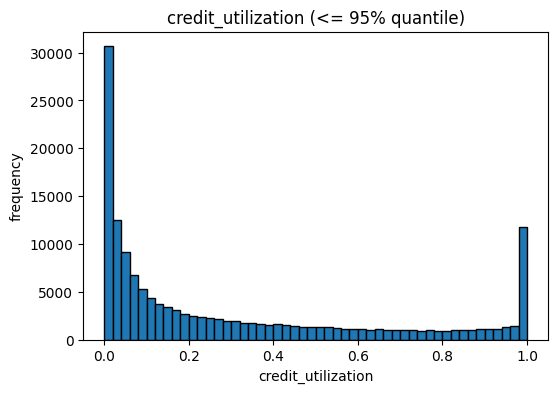

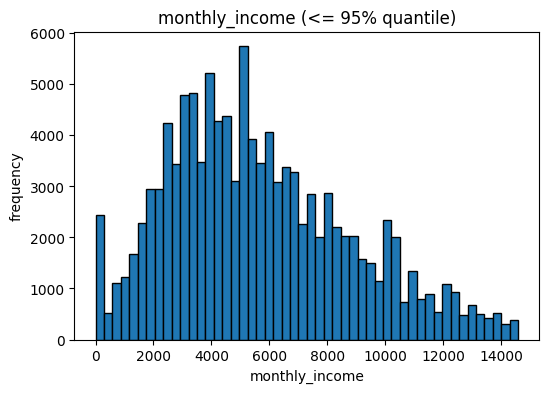

In [5]:
def plot_trimmed(feature):
    q = df[feature].quantile(0.95)

    plt.figure(figsize=(6, 4))
    plt.hist(df[df[feature] <= q][feature].dropna(), bins=50, edgecolor="black")
    plt.title(f"{feature} (<= 95% quantile)")
    plt.xlabel(feature)
    plt.ylabel("frequency")
    plt.show()

for feature in ["credit_utilization", "monthly_income"]:
    plot_trimmed(feature)


- Признак credit_utilization - это доля использованного кредитного лимита, он показывает, какую часть доступного кредита человек уже использует:

- $\text{credit_utilization} = \frac{\text{текущая задолженность}}{\text{кредитный лимит}}$

- credit_utilization актуальна только для кредитных карт и возобновляемых кредитных линий
	​
- Значения credit_utilization лежат в диапазоне от 0 до 1, где 1 означает, что лимит полностью исчерпан

- Большинство заёмщиков используют небольшую часть доступного кредитного лимита => они несильно зависимы от кредитных средств

- Признак monthly_income - это ежемесячный доход заёмщика

- Распределение monthly_income скошено вправо: большинство заёмщиков имеют относительно невысокий доход, при этом присутствует небольшое число заёмщиков с очень высоким доходом

Для этих признаков распределение сильно искажается из-за редких, но очень больших значений, поэтому ограничиваем значения сверху 95%-квантилем

Далее проверим максимальное значение признака credit_utilization:

In [6]:
df["credit_utilization"].max()

50708.0

- Получается, в столбце credit_utilization есть аномальные значения (максимальное среди них — 50708, что сильно больше единицы), которые, вероятно, возникают из-за деления на очень маленькое значение кредитного лимита или ошибок в данных, и не имеют экономического смысла

- Для корректной работы модели все значения этого признака > 1 заменим на единицу, тк они либо отражают перегруз по кредиту, либо являются особенностями данных, при этом точное значение уже не даёт дополнительной информации


Далее строим гистограмму для признака debt_ratio:



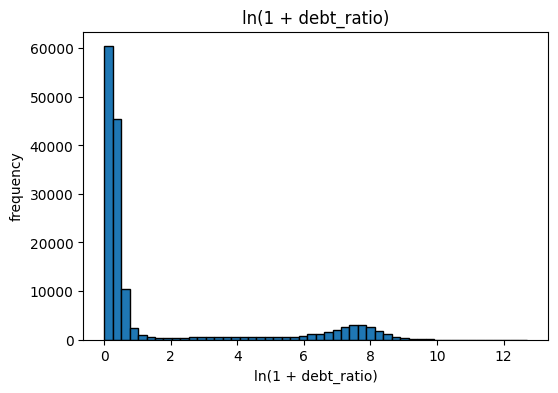

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(np.log1p(df["debt_ratio"].dropna()), bins=50, edgecolor="black")
plt.title("ln(1 + debt_ratio)")
plt.xlabel("ln(1 + debt_ratio)")
plt.ylabel("frequency")
plt.show()

- $debt\_ratio = \frac{\text{ежемесячные платежи по долгам}}{\text{ежемесячный доход}}$

- debt_ratio имеет смысл для всех видов кредитов

- debt_ratio тоже имеет сильную асимметрию и выбросы. При этом если попытаться также ограничить значения 95%-квантилем, распределение всё равно остаётся сильно скошенным, тк даже внутри этого диапазона большая часть наблюдений находится около нуля, а редкие большие значения продолжают искажать масштаб. Поэтому применяем ln(debt_ratio + 1)

- Большинство значений debt_ratio сосредоточено около нуля, то есть у большинства заёмщиков долговая нагрузка небольшая по сравнению с доходом

Теперь рассмотрим признаки, связанные с просрочками платежей:

- $late\_30\_59\_days$ — число случаев, когда заёмщик задерживал платеж на 30–59 дней
- $late\_60\_89\_days$ — число случаев, когда заёмщик задерживал платеж на 60–89 дней
- $late\_90\_days$ — число случаев, когда заёмщик задерживал платеж более чем на 90 дней


Это дискретные переменные, поэтому вместо гистограмм удобнее посмотреть частоты значений - это поможет понять, какие значения встречаются чаще всего и есть ли аномалии

In [8]:
for col in ["late_30_59_days", "late_60_89_days", "late_90_days"]:
    print(df[col].value_counts().sort_index().head(20))
    print()

late_30_59_days
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

late_60_89_days
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

late_90_days
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64



Видно, что большинство заёмщиков не допускают просрочек, а их случаи встречаются редко, но являются важным сигналом риска

Теперь рассмотрим признаки, показывающие количество кредитов на недвижимость.
Это также дискретные переменные, поэтому вместо гистограмм рассмотрим частоты значений:

In [14]:
df["real_estate_loans"].value_counts().sort_index()

,count
real_estate_loans,
0,56188
1,52338
2,31522
3,6300
4,2170
5,689
6,320
7,171
8,93


В признаке real_estate_loans встречаются отдельные большие значения (20 и более кредитов на недвижимость), которые выглядят нереалистично и нетипично для большинства заёмщиков

Такие наблюдения встречаются крайне редко, 1-3 раза каждое, поэтому вряд ли это специальная кодировка (иначе они бы систематически встречались гораздо чаще)

Так что, вероятно, эти наблюдения соответствуют специфическим случаям (возможно, инвестиции в недвижимость) или ошибке данных, но, поскольку их сравнительно мало, поэтому дополнительно обрабатывать их не будем

##Выводы по EDA:

- В непрерывных признаках (age, credit_utilization, debt_ratio, monthly_income):  

  Признак age имеет распределение, близкое к нормальному, и содержит незначительное количество аномалий

  В признаке credit_utilization есть аномальные значения, сильно превышающие единицу (при том, что credit_utilization может принимать только значения от 0 до 1), и эти значения мы далее заменим на единицу, тк они либо отражают перегруз по кредиту, либо являются особенностями данных, при этом точное значение уже не даёт дополнительной информации

  В признаках credit_utilization и monthly_income присутствуют редкие, но очень большие значения, которые искажают распределение, поэтому для анализа мы берем ограничение по 95%-квантилю  

  Признак debt_ratio имеет сильную асимметрию и длинный правый хвост, из-за чего даже после ограничения квантилем распределение остаётся скошенным — поэтому к нему применили $ln(\text{debt_ratio} + 1)$

- Большинство значений в столбцах значений просрочек платежей по кредитам (late_30_59_days, late_60_89_days и late_90_days) равны 0, то есть большинство заемщиков выплачивают все вовремя

  Но при этом довольно встречаются аномальные значения 96 и 98 - они не могут интерпретироваться как реальное количество просрочек, тк это означало бы множественные случаи серьёзных задержек платежей, что экономически маловероятно

  Поэтому мы предполагаем, что это ошибки или кодировка пропусков

  Дальше такие значения будут заменены на NaN

- В признаке real_estate_loans встречаются отдельные большие значения, нетипичные для большинства заёмщиков. Они наблюдаются крайне редко => это не кодировка пропусков, а либо специфические случаи, либо ошибки данных

  Поскольку таких наблюдений мало, дополнительная обработка не нужна


### Предобработка данных

По результатам EDA выполним обработку аномальных значений и пропусков

- Удаляем нереалистичные значения возрастов заемщиков:

In [23]:
df = df[(df["age"] > 0) & (df["age"] < 100)]

- Для столбцов значений просрочек платежей late_30_59_days, late_60_89_days, late_90_days считаем некорректными значениями 96 и 98;

- Для столбца credit_utilization, показывающего доли использованного кредитного лимита, все значения, большие 1, приводим к 1 (ограничиваем сверху):

In [9]:
import numpy as np

for col in ["late_30_59_days", "late_60_89_days", "late_90_days"]:
    df[col] = df[col].replace([96, 98], np.nan)

df["credit_utilization"] = df["credit_utilization"].clip(upper=1)

Смотрим, где сколько пропусков после того, как заменили аномальные значения на NaN:

In [10]:
df.isna().sum()

,0
Unnamed: 0,0
default,0
credit_utilization,0
age,0
late_30_59_days,269
debt_ratio,0
monthly_income,29731
num_credit_lines,0
late_90_days,269
real_estate_loans,0


- Пропуски в столбце с ежемесячным доходом заполняем медианой, тк она устойчива к выбросам;

- Пропуски в столбце с количеством иждивенцев тоже заполняем медианой;

- Пропуски в столбце с количеством просрочек платежей заполняем нулями:

In [11]:
df["monthly_income"] = df["monthly_income"].fillna(df["monthly_income"].median())
df["dependents"] = df["dependents"].fillna(df["dependents"].median())

for col in ["late_30_59_days", "late_60_89_days", "late_90_days"]:
    df[col] = df[col].fillna(0)

Проверяем, что пропусков больше нет:

In [12]:
df.isna().sum()

,0
Unnamed: 0,0
default,0
credit_utilization,0
age,0
late_30_59_days,0
debt_ratio,0
monthly_income,0
num_credit_lines,0
late_90_days,0
real_estate_loans,0


- Удаляем столбец с индексами, он не нужен:

In [13]:
df = df.drop(columns=["Unnamed: 0"])

- Для признака debt_ratio применяем логарифмическое преобразование, тк он имеет сильную асимметрию:

In [20]:
df["debt_ratio"] = np.log1p(df["debt_ratio"])

### Постановка задачи

Цель — построить модель, которая по характеристикам заёмщика будет предсказывать вероятность серьёзной просрочки платежа

Формально требуется оценить условную вероятность

$$
P(\text{default} = 1 \mid X),
$$

где $X$ — вектор признаков заёмщика

Переменная default принимает два значения:
- 0 — отсутствует серьёзная просрочка
- 1 — имеется просрочка более чем на 90 дней

То есть задача сводится к бинарной классификации: нужно по признакам заёмщика определить, будет ли он относиться к классу с дефолтом или без, то есть допустит ли он просрочку более чем на 90 дней в ближайшие два года

### Выбор моделей и метрик

Для решения задачи бинарной классификации будем использовать следующие модели:
- логистическую регрессию
- kNN

Логистическая регрессия выбрана как базовая модель, тк она позволяет напрямую оценивать вероятность дефолта и хорошо интерпретируется: можно понять, как признаки влияют на риск

Метод kNN рассматривается как более гибкий алгоритм, который не делает предположений о виде зависимости и может учитывать локальную структуру данных. Но он хуже работает, когда один класс встречается намного чаще другого (как в нашем случае, где дефолтов около 7%, а не дефолтов где-то 93%). Поэтому основным алгоритмом будет логистическая регрессия

Для оценки качества моделей будем использовать следующие метрики:
- accuracy
- ROC-AUC

Метрика accuracy показывает долю правильно классифицированных наблюдений. Но целевая переменная является несбалансированной: доля дефолтов значительно меньше доли недефолтов. В таких условиях accuracy может давать завышенную оценку качества модели, так как модель может достигать высокой точности, просто предсказывая наиболее частый класс

Поэтому для оценки качества дополнительно используется метрика ROC-AUC, и ориентироваться, в основном, будем на нее

ROC-AUC позволяет оценивать, насколько хорошо модель расставляет заёмщиков по уровню риска — от более надёжных к более рискованным, и не зависит от выбранного порога классификации

